In [1]:
%pip install tensorflow pillow numpy huggingface_hub ipywidgets matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import json
import numpy as np
import tensorflow as tf
from PIL import Image
from io import BytesIO
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
from huggingface_hub import hf_hub_download

In [3]:
import json

model_path = "./model_float16_quant.tflite";
labels_path = "./class_indices.json";

with open(labels_path, "r") as f:
    class_map = json.load(f)

print("Number of classes:", len(class_map))

for i in range(5):
    print(i, "->", class_map[str(i)])

Number of classes: 38
0 -> Apple___Apple_scab
1 -> Apple___Black_rot
2 -> Apple___Cedar_apple_rust
3 -> Apple___healthy
4 -> Blueberry___healthy


In [4]:
interpreter = tf.lite.Interpreter(model_path=model_path)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print(input_details)

[{'name': 'image', 'index': 0, 'shape': array([  1, 384, 384,   3], dtype=int32), 'shape_signature': array([ -1, 384, 384,   3], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0, 'block_size': 0}, 'sparsity_parameters': {}}]


c:\Users\soumy\AppData\Local\Programs\Python\Python313\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [5]:
IMG_SIZE = input_details[0]["shape"][1]
print("Model input size:", IMG_SIZE)

Model input size: 384


In [6]:
def preprocess_pil_image(img):
    img = img.resize((IMG_SIZE, IMG_SIZE))
    arr = np.array(img, dtype=np.float32)
    arr = np.expand_dims(arr, axis=0)
    return arr

In [7]:
def predict_leaf(img, top_k=5):

    image = preprocess_pil_image(img)

    interpreter.set_tensor(
        input_details[0]["index"],
        image
    )

    interpreter.invoke()

    preds = interpreter.get_tensor(
        output_details[0]["index"]
    )[0]

    top_indices = np.argsort(preds)[-top_k:][::-1]

    results = []
    for idx in top_indices:
        results.append({
            "class": class_map[str(idx)],
            "confidence": float(preds[idx])
        })

    return results

In [8]:
upload = widgets.FileUpload(
    accept='image/*',
    multiple=False
)

display(upload)

FileUpload(value=(), accept='image/*', description='Upload')

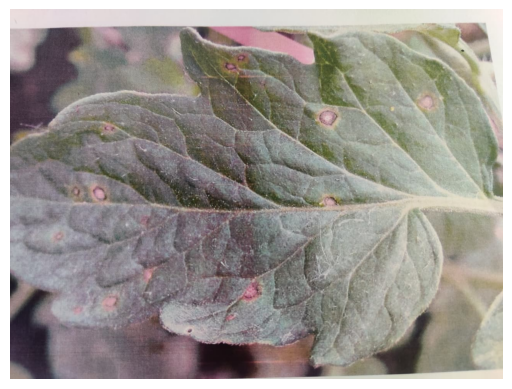

In [12]:
file_info = upload.value

# VS Code returns tuple or dict depending on version
if isinstance(file_info, tuple):
    file_info = file_info[0]
else:
    file_info = list(file_info.values())[0]

image_bytes = file_info["content"]

img = Image.open(BytesIO(image_bytes)).convert("RGB")

plt.imshow(img)
plt.axis("off")
plt.show()

In [13]:
results = predict_leaf(img)

for r in results:
    print(f"{r['class']} : {r['confidence'] * 100:.2f}%")

Potato___Early_blight : 15.46%
Grape___Black_rot : 14.89%
Squash___Powdery_mildew : 9.97%
Soybean___healthy : 4.25%
Corn___Cercospora_leaf_spot Gray_leaf_spot : 4.08%


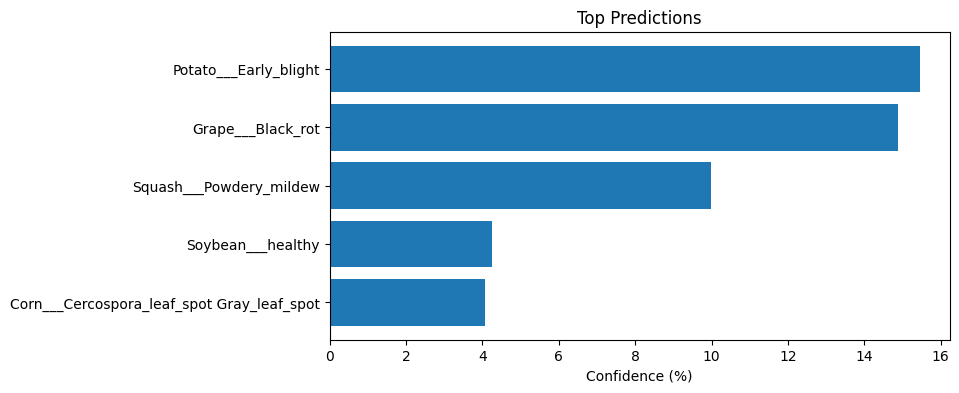

In [14]:
labels = [r["class"] for r in results]
scores = [r["confidence"] * 100 for r in results]

plt.figure(figsize=(8,4))
plt.barh(labels, scores)
plt.xlabel("Confidence (%)")
plt.title("Top Predictions")
plt.gca().invert_yaxis()
plt.show()